In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
players = pd.read_csv('./data/players_20.csv')
print(players.info())
players.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB
None


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [3]:
lables = players['player_positions'].str.split(',').str[0]

In [4]:
players.drop(columns=['gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning',
                      'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 
                      'goalkeeping_reflexes', 'goalkeeping_diving', 'team_position', 'player_positions', 'release_clause_eur', 'team_jersey_number', 'contract_valid_until', 'nation_jersey_number'], 
             inplace=True)

In [5]:
players = players[~lables.isin(['GK']) | lables.isna()]
lables = lables[~lables.isin(['GK']) | lables.isna()]
data = pd.concat([players, lables], axis=1)

In [6]:
classes = np.unique(lables)

lables, unique_values = pd.factorize(lables)

lables_df = pd.DataFrame({'label': lables})

print("Mapped Labels:")
print(lables_df)
print("\nUnique Categories Mapping:")
print(dict(enumerate(unique_values)))

Mapped Labels:
       label
0          0
1          1
2          2
3          2
4          3
...      ...
16237      4
16238      4
16239      5
16240      5
16241      5

[16242 rows x 1 columns]

Unique Categories Mapping:
{0: 'RW', 1: 'ST', 2: 'LW', 3: 'CAM', 4: 'CB', 5: 'CM', 6: 'CDM', 7: 'CF', 8: 'LB', 9: 'RB', 10: 'RM', 11: 'LM', 12: 'LWB', 13: 'RWB'}


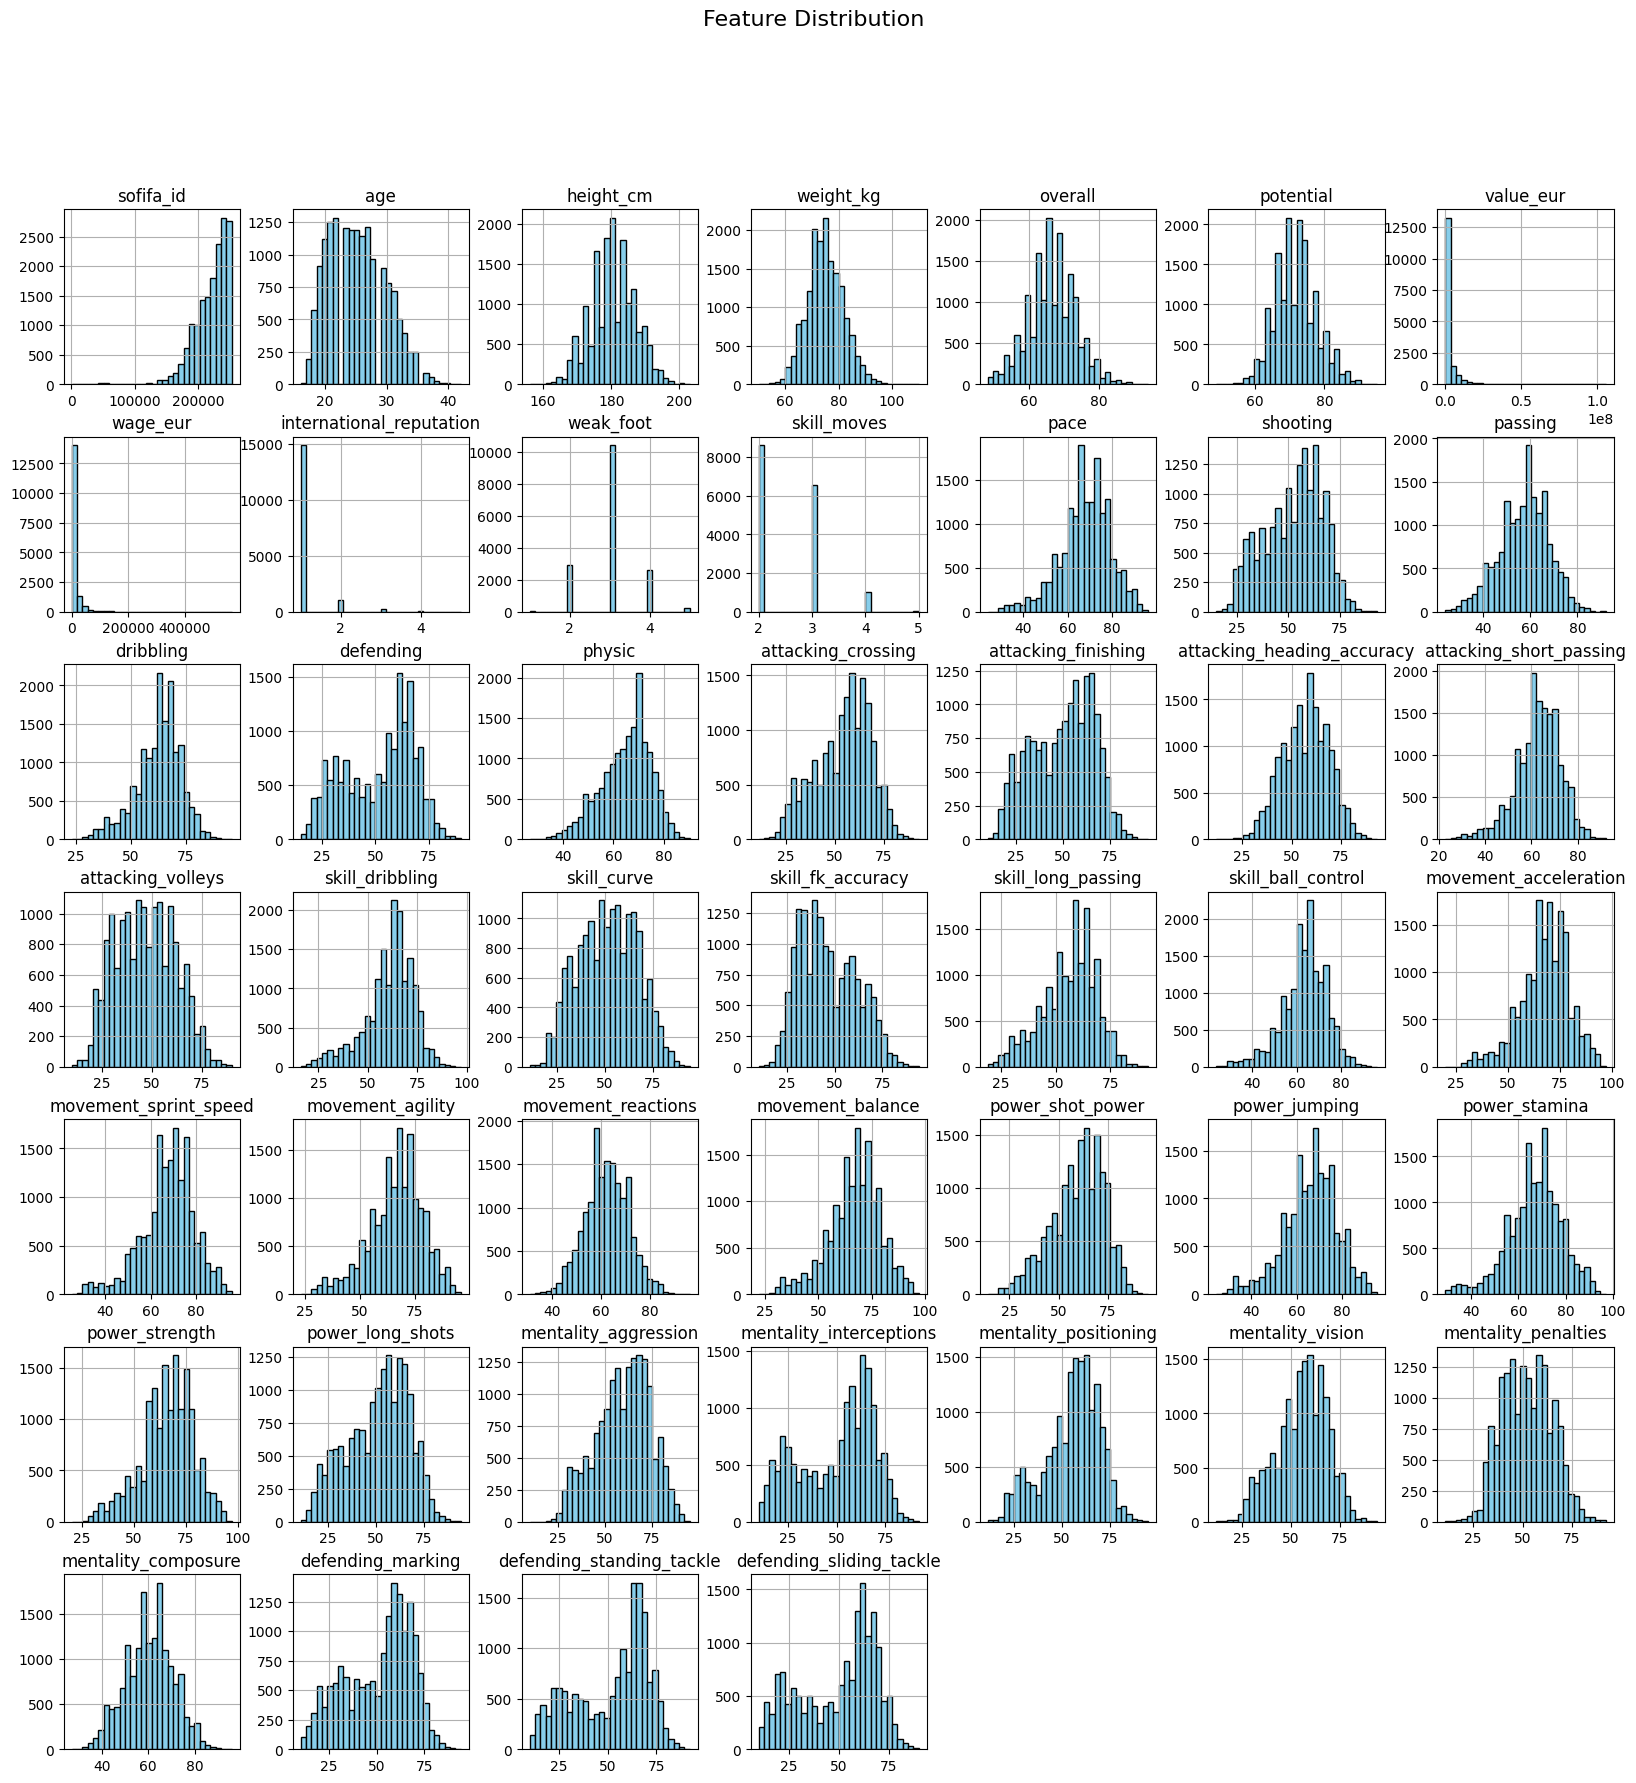

In [7]:
players.hist(bins=30, figsize=(20, 20), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distribution", fontsize=16)
plt.show()

In [7]:
numerical_columns = players.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical features:", numerical_columns)

numerical_players = players[numerical_columns]

Numerical features: ['sofifa_id', 'age', 'height_cm', 'weight_kg', 'overall', 'potential', 'value_eur', 'wage_eur', 'international_reputation', 'weak_foot', 'skill_moves', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure', 'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle']


# Part 1

/var/folders/9w/ft0tywhn76j1gh647345mmy80000gn/T/ipykernel_78173/2182307520.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_players['cluster'] = kmeans.fit_predict(X_scaled)


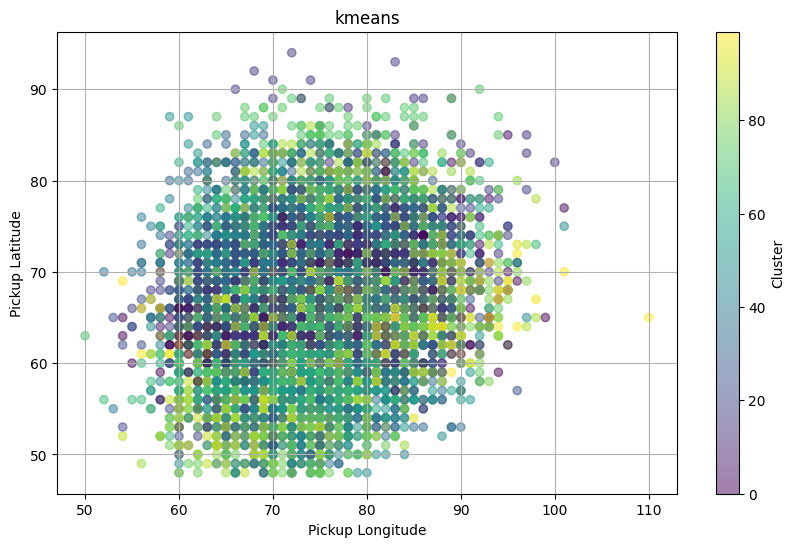

In [25]:
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numerical_players)

# Perform K-means clustering
kmeans = KMeans(n_clusters=100, random_state=42, n_init=10)
numerical_players['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(numerical_players['weight_kg'], numerical_players['overall'], c=numerical_players['cluster'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Cluster')
plt.xlabel('Pickup Longitude')
plt.ylabel('Pickup Latitude')
plt.title('kmeans')
plt.grid(True)
plt.show()

Estimated number of clusters: 11
Estimated number of noise points: 12461
Silhouette Score: -0.307


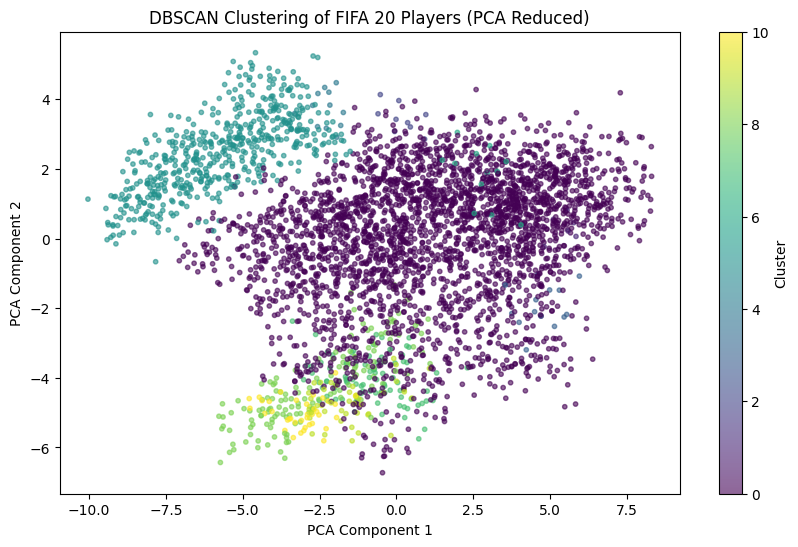

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numerical_players)

eps = 3
min_samples = 12
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f'Estimated number of clusters: {n_clusters}')
print(f'Estimated number of noise points: {n_noise}')

mask = labels != -1
X_filtered = X_scaled[mask]
filtered_labels = labels[mask]
gt = lables_df['label'][mask]

if n_clusters > 1:
    silhouette = silhouette_score(X_scaled, labels)
    print(f'Silhouette Score: {silhouette:.3f}')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_filtered)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=filtered_labels, cmap='viridis', s=10, alpha=0.6)
plt.title('DBSCAN Clustering of FIFA 20 Players (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

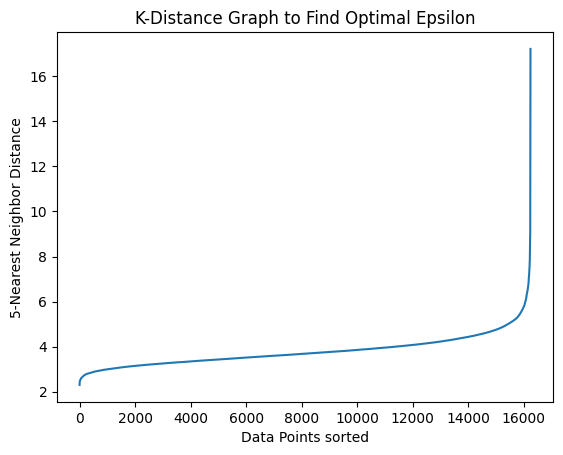

In [36]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=12)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.title("K-Distance Graph to Find Optimal Epsilon")
plt.xlabel("Data Points sorted")
plt.ylabel("5-Nearest Neighbor Distance")
plt.show()

# GT

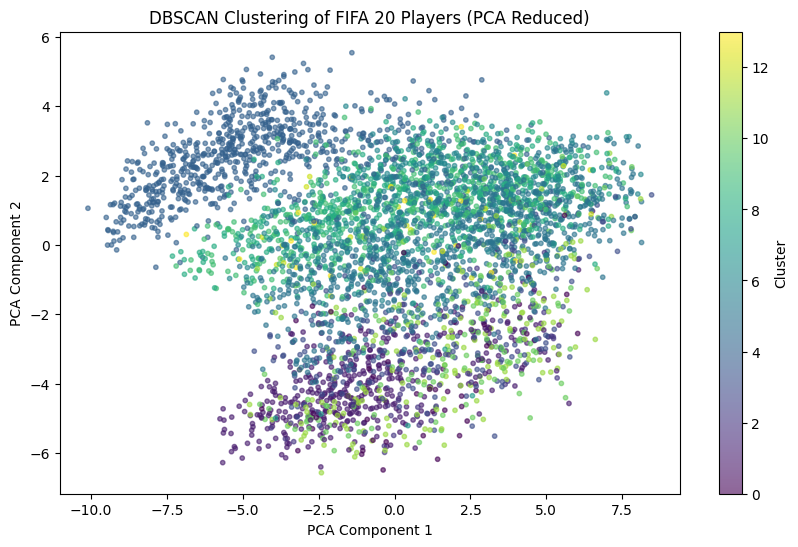

In [89]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gt, cmap='viridis', s=10, alpha=0.6)
plt.title('DBSCAN Clustering of FIFA 20 Players (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

Estimated number of clusters: 6
Estimated number of noise points: 195
Silhouette Score: 0.613


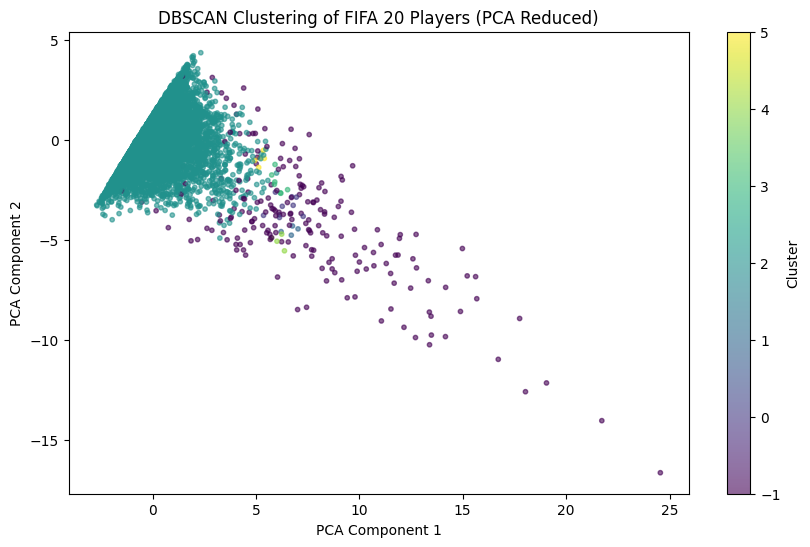

In [48]:
x_data = players[['height_cm', 'weight_kg','value_eur', 'wage_eur']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_data)

eps = 0.85
min_samples = 4
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f'Estimated number of clusters: {n_clusters}')
print(f'Estimated number of noise points: {n_noise}')

if n_clusters > 1:
    silhouette = silhouette_score(X_scaled, labels)
    print(f'Silhouette Score: {silhouette:.3f}')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
plt.title('DBSCAN Clustering of FIFA 20 Players (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

Estimated number of clusters: 3
Estimated number of noise points: 51
Silhouette Score: 0.772


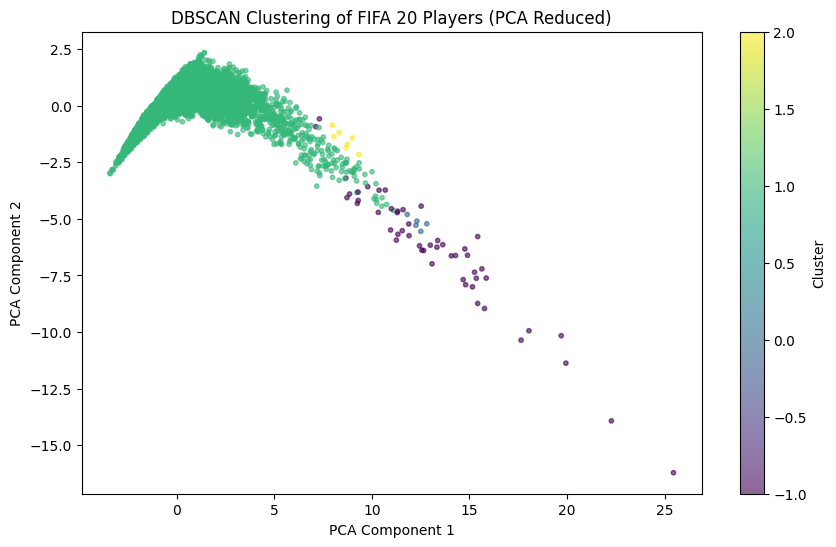

In [48]:
features = [
    'overall', 'potential', 
      'value_eur', 'wage_eur'
]
X = players[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

eps = 1
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f'Estimated number of clusters: {n_clusters}')
print(f'Estimated number of noise points: {n_noise}')

if n_clusters > 1:
    silhouette = silhouette_score(X_scaled, labels)
    print(f'Silhouette Score: {silhouette:.3f}')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
plt.title('DBSCAN Clustering of FIFA 20 Players (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

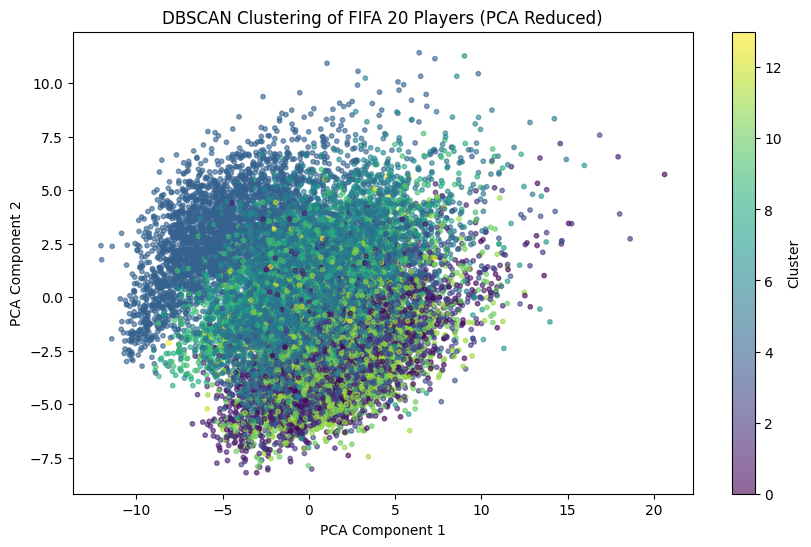

In [62]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=lables_df['label'], cmap='viridis', s=10, alpha=0.6)
plt.title('DBSCAN Clustering of FIFA 20 Players (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()